# Linear Regression, Polynomial Fit
changed from  https://jakevdp.github.io/PythonDataScienceHandbook/05.06-linear-regression.html 

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

[1.73496987 5.41963058 4.63098605]
[-4.14061431  6.89114742  3.45143824]
(50,)
(50,)


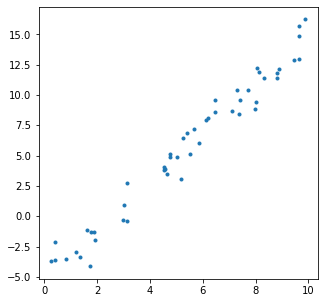

In [53]:
# create two numpy arrays of shape (50,)

# create container for random number generators
# rng = np.random.RandomState(seed=1)  # specific seed - generates the same numbers
rng = np.random.RandomState(seed=None)
x = 10 * rng.rand(50)                # 50 random numbers in [0,10] 
y = 2 * x - 5 + rng.randn(50)        # 50 numbers between [-5, 15] 
                                     # linear function of x plus some normal noise
print(x[:3])
print(y[:3])
print(np.shape(x))
print(np.shape(y))

%matplotlib inline
plt.rcParams["figure.figsize"] = (5, 5) # (width, height)
fig, ax = plt.subplots()
_ = ax.scatter(x,y, marker='.');
_ = plt.show();

In [54]:
# below we will use "newaxis" to convert array to column array.
# https://stackoverflow.com/questions/29241056/how-does-numpy-newaxis-work-and-when-to-use-it
# Here is an example of how it works
aa = np.array(range(5))
print("aa = ", aa)
bb = aa[:, np.newaxis]
print("bb = ", bb)

aa =  [0 1 2 3 4]
bb =  [[0]
 [1]
 [2]
 [3]
 [4]]


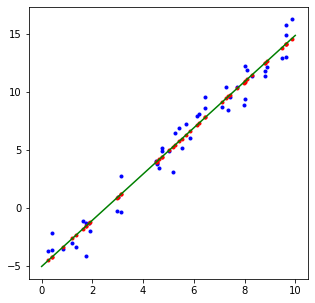

In [55]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=True)
model.fit(x[:, np.newaxis], y)   # here x - one or more columns, y - row

# create numpy array of shape (1000,) with values in [0,10]
xt = np.linspace(0, 10, 1000)
# print(xt)
# print(type(xt))
# print(np.shape(xt))
yt = model.predict(xt[:, np.newaxis]) # this will draw a model line
yp = model.predict(x[:, np.newaxis])
fig, ax = plt.subplots()
_ = ax.scatter(x,y,  marker='.', color='blue');
_ = ax.scatter(x,yp, marker='.', color='red');
_ = ax.plot(xt, yt, color='green');
_ = plt.show();

In [56]:
# The coefficients
slope     = model.coef_[0]
intercept = model.intercept_
print(f"slope = {slope:.3f}, intercept = {intercept:.3f}")
print(f"Mean squared error : {mean_squared_error(y,yp):.2f}")
print(f"R2 Variance score  : {r2_score(y, yp):.2f}")

slope = 1.990, intercept = -5.043
Mean squared error : 1.13
R2 Variance score  : 0.97


### ---------------------------------------------------------------

## Polinomial Fit Demo

- Generate polinomial function with random noise
- Fit it using polinomial fit

In [34]:
# generate 1000 random numbers with values in range [0-10]
rng = np.random.RandomState(seed=1)
N=1000
x = 10 * rng.rand(N)
x = np.where(x<0.0001, 0.0001, x)
print(f"x.shape = {x.shape}")
print(f"x[:10] = {np.round(x[:10],2)}")

x.shape = (1000,)
x[:10] = [4.17 7.2  0.   3.02 1.47 0.92 1.86 3.46 3.97 5.39]


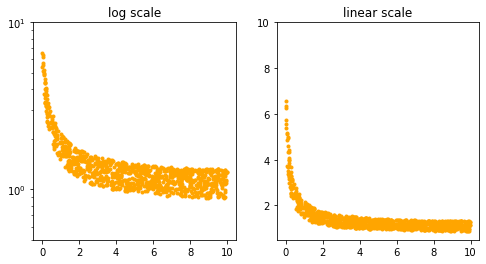

In [35]:
# add randomness
x2 = 0.4 * rng.rand(N) - 0.2

# create y as a function of x and randomness
y = (1+1/(0.2+x))*(1+x2)

# plot y vs x
plt.rcParams["figure.figsize"] = (8, 4) # (width, height) 
fig,(ax1,ax2) = plt.subplots(1,2)
for ax in [ax1,ax2]:
    _ = ax.scatter(x,y, marker='.', color='orange')
    _ = ax.set_ylim(bottom=5e-1, top=10)
_ = ax1.set_yscale("log")
_ = ax2.set_yscale("linear")
_ = ax1.set_title("log scale")
_ = ax2.set_title("linear scale")
plt.show();

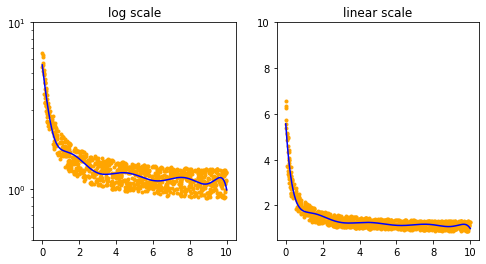

In [36]:
# polinomial fit
a  = np.array(x) # copy
b  = np.array(y) # copy

p9 = np.poly1d(np.polyfit(a,b,9))

xp = np.linspace(0,10,300)

plt.rcParams["figure.figsize"] = (8, 4) # (width, height) 
fig,(ax1,ax2) = plt.subplots(1,2)
for ax in [ax1,ax2]:
    _ = ax.scatter(x,y, marker='.', color='orange')
    _ = ax.plot(xp, p9(xp), color='blue')
    _ = ax.set_ylim(bottom=5e-1, top=10)
_ = ax1.set_yscale("log")
_ = ax2.set_yscale("linear")
_ = ax1.set_title("log scale")
_ = ax2.set_title("linear scale")
plt.show();